# 04 — Customer Lifetime Value (CLV) Modelling

**Goal:** Calculate historical CLV per customer and segment, then predict future CLV using the BG/NBD model.

**Inputs:** `../data/cleaned/rfm_segments.csv`, `../data/cleaned/master_transactions.csv`  
**Output:** `../data/cleaned/clv_scores.csv`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    from lifetimes import BetaGeoFitter, GammaGammaFitter
    from lifetimes.utils import summary_data_from_transaction_data
    LIFETIMES_AVAILABLE = True
    print('lifetimes library available — BG/NBD model will be used')
except ImportError:
    LIFETIMES_AVAILABLE = False
    print('lifetimes not installed — using simplified CLV model')
    print('Install with: pip install lifetimes')

CLEAN_PATH = '../data/cleaned/'

rfm = pd.read_csv(CLEAN_PATH + 'rfm_segments.csv', parse_dates=['first_order', 'last_order'])
transactions = pd.read_csv(CLEAN_PATH + 'master_transactions.csv', parse_dates=['order_date'])
print(f'Loaded {len(rfm):,} customers and {len(transactions):,} transactions')

lifetimes library available — BG/NBD model will be used
Loaded 93,349 customers and 96,469 transactions


## 2. Historical CLV

In [2]:
# Simple historical CLV = total spend per customer
clv = rfm[['customer_id', 'Segment', 'frequency', 'monetary',
            'avg_order_value', 'recency', 'R', 'F', 'M']].copy()
clv = clv.rename(columns={'monetary': 'historical_clv'})

# CLV tiers
clv['clv_tier'] = pd.qcut(
    clv['historical_clv'],
    q=4,
    labels=['Low Value', 'Mid Value', 'High Value', 'Top Value']
)

tier_summary = clv.groupby('clv_tier', observed=True).agg(
    customers=('customer_id', 'count'),
    total_clv=('historical_clv', 'sum'),
    avg_clv=('historical_clv', 'mean'),
    avg_orders=('frequency', 'mean')
).round(2)
tier_summary['pct_revenue'] = (tier_summary['total_clv'] / clv['historical_clv'].sum() * 100).round(1)

print('CLV Tier Summary:')
tier_summary

CLV Tier Summary:


,customers,total_clv,avg_clv,avg_orders,pct_revenue
clv_tier,,,,,
Low Value,23338,1017383.65,43.59,1.00,6.6
Mid Value,23341,1950232.97,83.55,1.01,12.6
High Value,23333,3289339.97,140.97,1.03,21.3
Top Value,23337,9164126.26,392.69,1.09,59.4


## 3. Predictive CLV — BG/NBD Model (if lifetimes available)

In [3]:
if LIFETIMES_AVAILABLE:
    # Prepare data in the format lifetimes expects
    # customer_unique_id maps to customer_id in our table
    trans_for_lifetimes = transactions[['customer_id_unique', 'order_date', 'total_payment']].copy()
    trans_for_lifetimes.columns = ['customer_id', 'date', 'monetary_value']

    observation_period_end = trans_for_lifetimes['date'].max()

    summary = summary_data_from_transaction_data(
        trans_for_lifetimes,
        customer_id_col='customer_id',
        datetime_col='date',
        monetary_value_col='monetary_value',
        observation_period_end=observation_period_end
    )

    # Fit BG/NBD model (predicts purchase frequency)
    bgf = BetaGeoFitter(penalizer_coef=0.0)
    bgf.fit(summary['frequency'], summary['recency'], summary['T'])
    print('BG/NBD model fitted')

    # Predict expected purchases in next 12 months
    summary['predicted_purchases_12m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
        12 * 4,   # 12 months in weeks approx
        summary['frequency'], summary['recency'], summary['T']
    )

    # Fit Gamma-Gamma model (predicts avg transaction value)
    returning = summary[summary['frequency'] > 0]
    ggf = GammaGammaFitter(penalizer_coef=0)
    ggf.fit(returning['frequency'], returning['monetary_value'])
    print('Gamma-Gamma model fitted')

    # Predicted CLV for next 12 months
    clv_predicted = ggf.customer_lifetime_value(
        bgf,
        summary['frequency'],
        summary['recency'],
        summary['T'],
        summary['monetary_value'],
        time=12,
        freq='W'
    ).reset_index()
    clv_predicted.columns = ['customer_id', 'predicted_clv_12m']

    clv = clv.merge(clv_predicted, on='customer_id', how='left')
    print(f'Predicted CLV added for {clv["predicted_clv_12m"].notna().sum():,} customers')
    print(f'Avg predicted 12m CLV: {clv["predicted_clv_12m"].mean():.2f} BRL')

else:
    # Simplified predictive CLV: avg order value x purchase frequency x estimated lifespan
    AVG_LIFESPAN_MONTHS = 24
    clv['predicted_clv_12m'] = (
        clv['avg_order_value'] *
        (clv['frequency'] / (rfm['tenure_days'].clip(lower=1) / 30)) *
        12
    ).clip(lower=0)
    print('Simplified CLV model applied (install lifetimes for BG/NBD)')

BG/NBD model fitted
Gamma-Gamma model fitted
Predicted CLV added for 93,349 customers
Avg predicted 12m CLV: 0.52 BRL


## 4. Visualise CLV

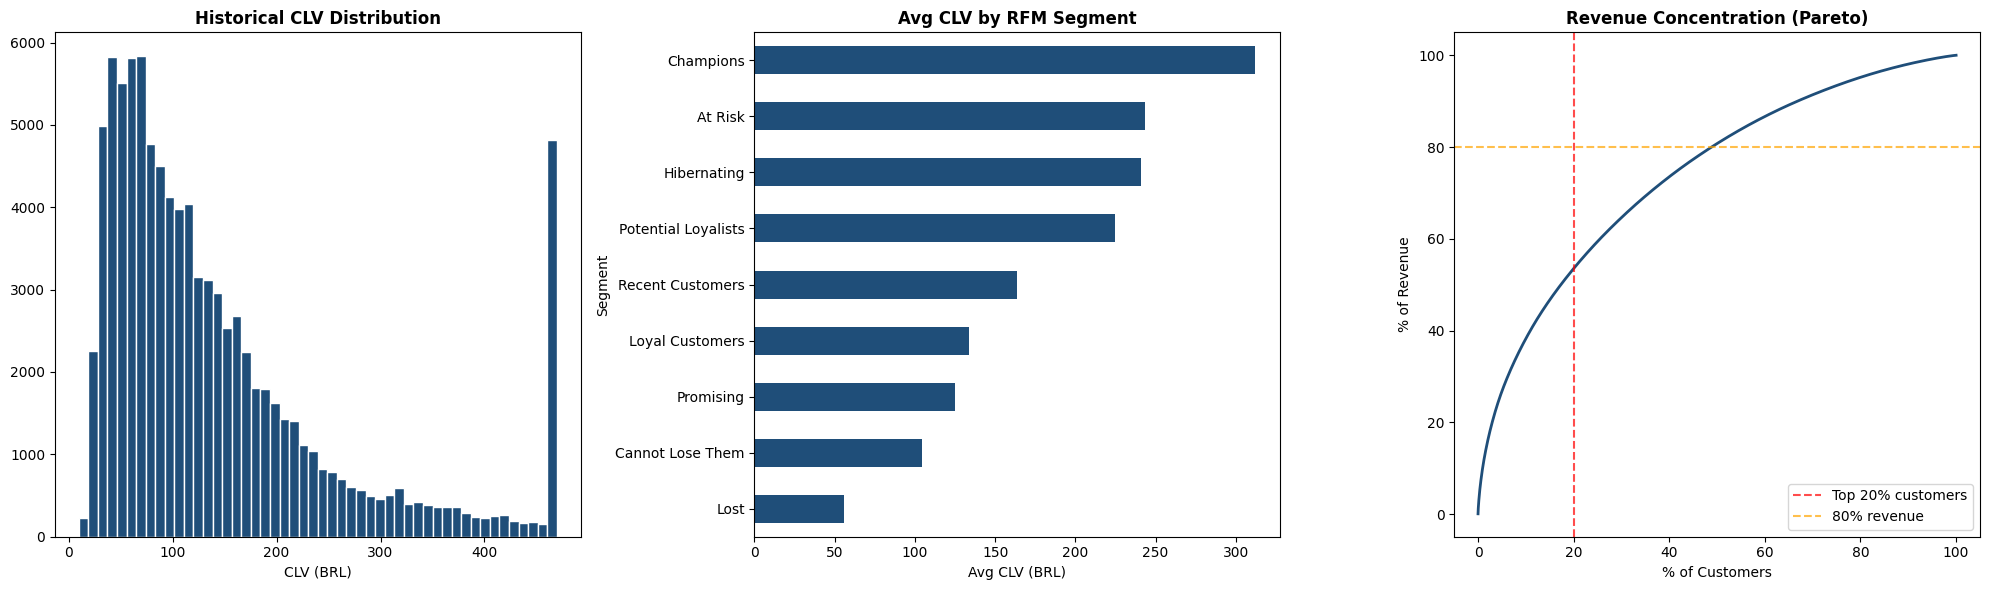

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# CLV distribution
axes[0].hist(clv['historical_clv'].clip(upper=clv['historical_clv'].quantile(0.95)),
             bins=50, color='#1F4E79', edgecolor='white')
axes[0].set_title('Historical CLV Distribution', fontweight='bold')
axes[0].set_xlabel('CLV (BRL)')

# CLV by segment
segment_clv = clv.groupby('Segment')['historical_clv'].mean().sort_values(ascending=True)
segment_clv.plot.barh(ax=axes[1], color='#1F4E79')
axes[1].set_title('Avg CLV by RFM Segment', fontweight='bold')
axes[1].set_xlabel('Avg CLV (BRL)')

# Revenue concentration (Pareto)
clv_sorted = clv['historical_clv'].sort_values(ascending=False).reset_index(drop=True)
cumulative_pct_revenue = clv_sorted.cumsum() / clv_sorted.sum() * 100
cumulative_pct_customers = (clv_sorted.index + 1) / len(clv_sorted) * 100
axes[2].plot(cumulative_pct_customers, cumulative_pct_revenue, color='#1F4E79', linewidth=2)
axes[2].axvline(20, color='red', linestyle='--', alpha=0.7, label='Top 20% customers')
axes[2].axhline(80, color='orange', linestyle='--', alpha=0.7, label='80% revenue')
axes[2].set_title('Revenue Concentration (Pareto)', fontweight='bold')
axes[2].set_xlabel('% of Customers')
axes[2].set_ylabel('% of Revenue')
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/04_clv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Save Output

In [5]:
clv.to_csv(CLEAN_PATH + 'clv_scores.csv', index=False)
print(f'Saved clv_scores.csv — {len(clv):,} customers')
print(f'Total historical CLV: {clv["historical_clv"].sum():,.2f} BRL')
if 'predicted_clv_12m' in clv.columns:
    print(f'Total predicted CLV (12m): {clv["predicted_clv_12m"].sum():,.2f} BRL')

Saved clv_scores.csv — 93,349 customers
Total historical CLV: 15,421,082.85 BRL
Total predicted CLV (12m): 48,304.43 BRL


## Summary

| Metric | Value |
|---|---|
| Top 20% customers revenue share | *(fill in)* |
| Avg CLV — Champions segment | *(fill in)* |
| Avg predicted 12m CLV | *(fill in)* |

**Next:** Run `05_campaign_evaluation.ipynb`